# Linear Modeling: From Theory to Toolset

## Table of Content

- [1. Data Audit & Cleaning](#1)
    - [1.1 Variable Inventory & Type Check](#1.1)
    - [1.2 Data Cleaning (Handling Missing Values)](#1.2)
    - [1.3 Linearity & Correlation Check](#1.3)
    - [1.4 Encoding Qualitative Data](#1.4)
    - [1.5 Feature Scaling (Standardization)](#1.5)
- [2. The Baseline Model (Inference)](#2)
    - [2.1 Fitting the OLS Model](#2.1)
    - [2.2 The Analyst's Checklist (The "Three Pillars")](#2.2)
- [3. Validation Strategy](#3)
    - [3.1 The Train-Test Split](#3.1)
    - [3.2 Performance Metrics](#3.2)
    - [3.3 K-Fold Cross-Validation](#3.3)
    - [3.4 Visual Validation](#3.4)
- [4. Model Refinement (Flexibility & Regularization)](#4)
    - [4.1 Feature Engineering](#4.1)
    - [4.2 Automated Regularization (Ridge & Lasso)](#4.2)
    - [4.3 Evaluating the "Shrinkage"](#4.3)
- [5. Final Evaluation (The Result)](#5)
- [6. The Post-Mortem (Troubleshooting)](#6)
    - [6.1 Identify the "Failure Mode"](#6.1)
    - [6.2 The "Outlier" Audit](#6.2)
    - [6.3 Checking for Multi-Collinearity (VIF)](#6.3)

<a id="1"></a>
## Phase 1: Data Audit & Cleaning
**Goal**: Interrogate, clean, and prepare the raw data for statistical modeling.

<a id="1.1"></a>
### 1.1 Variable Inventory & Type Check
Before modeling, we must identify the nature of our variables. Regression requires a quantitative $Y$, while Classification requires a qualitative $Y$.

- The Target ($Y$): mpg (Quantitative).
- The Predictors ($X$): horsepower, weight, acceleration, year, origin.
- *Manual Rule*: Always verify the "Type" in Python using df.info(). Sometimes numbers are stored as "objects" (strings), which will crash your model.

In [3]:
import pandas as pd

# Load the dataset
auto_df = pd.read_csv('Auto.csv')

# 1. Check data types and missing values
display(auto_df.info())

# 2. Preview the first few rows
auto_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392 entries, 0 to 391
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    int64  
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    object 
dtypes: float64(3), int64(5), object(1)
memory usage: 27.7+ KB


None

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,name
0,18.0,8,307.0,130,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140,3449,10.5,70,1,ford torino


<a id="1.2"></a>
### 1.2 Data Cleaning (Handling Missing Values)
Statistical models cannot handle NaN or null values. We must decide whether to drop or impute.

- Step A: Identification: Replace non-standard missing values (like ?) with NaN.
- Step B: The Decision Matrix:
    - Option 1: Dropping. If missing values are rare (like the 5 rows in Auto), delete them.
    - Option 2: Imputation. If you have a small dataset and can't afford to lose rows, fill the gaps with the Median (more robust to outliers) or the Mean.

*Note: The ISLP Auto dataset is pre-cleaned, but in a real-world scenario, you might find placeholders like '?'.*

In [6]:
import numpy as np

# Replace common placeholders with actual NaN
auto_df.replace('?', np.nan, inplace=True)

# Identify missing counts
print("Missing values per column: \n", auto_df.isnull().sum())

# Decision: Drop rows with missing values (Standard ISLP approach)
auto_df = auto_df.dropna()

Missing values per column: 
 mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
year            0
origin          0
name            0
dtype: int64


<a id="1.3"></a>
### 1.3 Linearity & Correlation Check
Linear models assume an additive relationship. We use visualization to flag variables that might require non-linear transformations later.

In [21]:
auto_df.describe().T

,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.445918,7.805007,9.0,17.000,22.75,29.000,46.6
cylinders,392.0,5.471939,1.705783,3.0,4.000,4.00,8.000,8.0
displacement,392.0,194.411990,104.644004,68.0,105.000,151.00,275.750,455.0
horsepower,392.0,104.469388,38.491160,46.0,75.000,93.50,126.000,230.0
weight,392.0,2977.584184,849.402560,1613.0,2225.250,2803.50,3614.750,5140.0
acceleration,392.0,15.541327,2.758864,8.0,13.775,15.50,17.025,24.8
year,392.0,75.979592,3.683737,70.0,73.000,76.00,79.000,82.0
origin,392.0,1.576531,0.805518,1.0,1.000,1.00,2.000,3.0


- What you observe: The scale (min/max), the central tendency (mean/median), and the spread (standard deviation) of every variable.

- Why it’s useful: * Scale Detection: You’ll see that weight is in the thousands while acceleration is in the tens. This tells you that Standardization is mandatory if you plan to use Ridge/Lasso.

- Outlier Scouting: If the max is significantly higher than the 75% percentile (the "mean + 3 std dev" rule), you have outliers that might pull a linear regression line away from the bulk of the data.

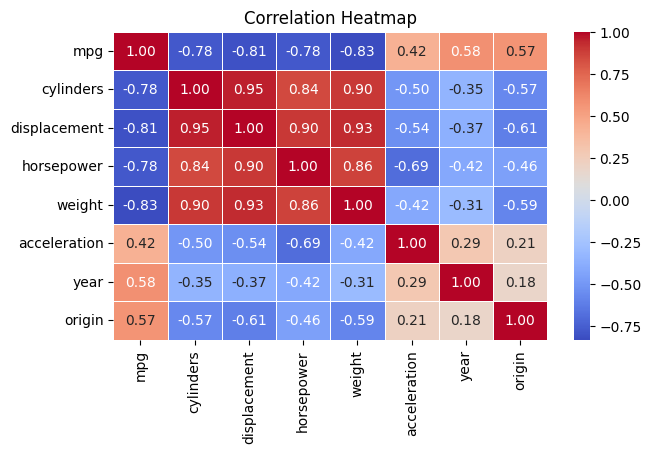

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = auto_df.select_dtypes(include=['number']).corr()

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(corr_matrix, 
            annot=True,      # This puts the actual numbers inside the squares
            cmap='coolwarm', # The color scheme (red for positive, blue for negative)
            fmt='.2f',       # Limits the numbers to 2 decimal places
            linewidths=0.5,  # Adds a tiny gap between squares for readability
            ax=ax)           # Tells seaborn to draw on our 'ax' canvas

ax.set_title('Correlation Heatmap')
plt.show()

- What you observe: The "redundancy" between predictors and the "strength" of the signal toward the target.
- Why it’s useful: * Spotting Multicollinearity: If two predictors (like displacement and weight) have a correlation of $0.90+$, they are telling the same story. Including both can make your coefficient estimates unstable and inflate p-values.
- Prioritizing Features: It gives you an immediate hint of which variables are the "stars of the show" (those with high positive or negative correlation with mpg).

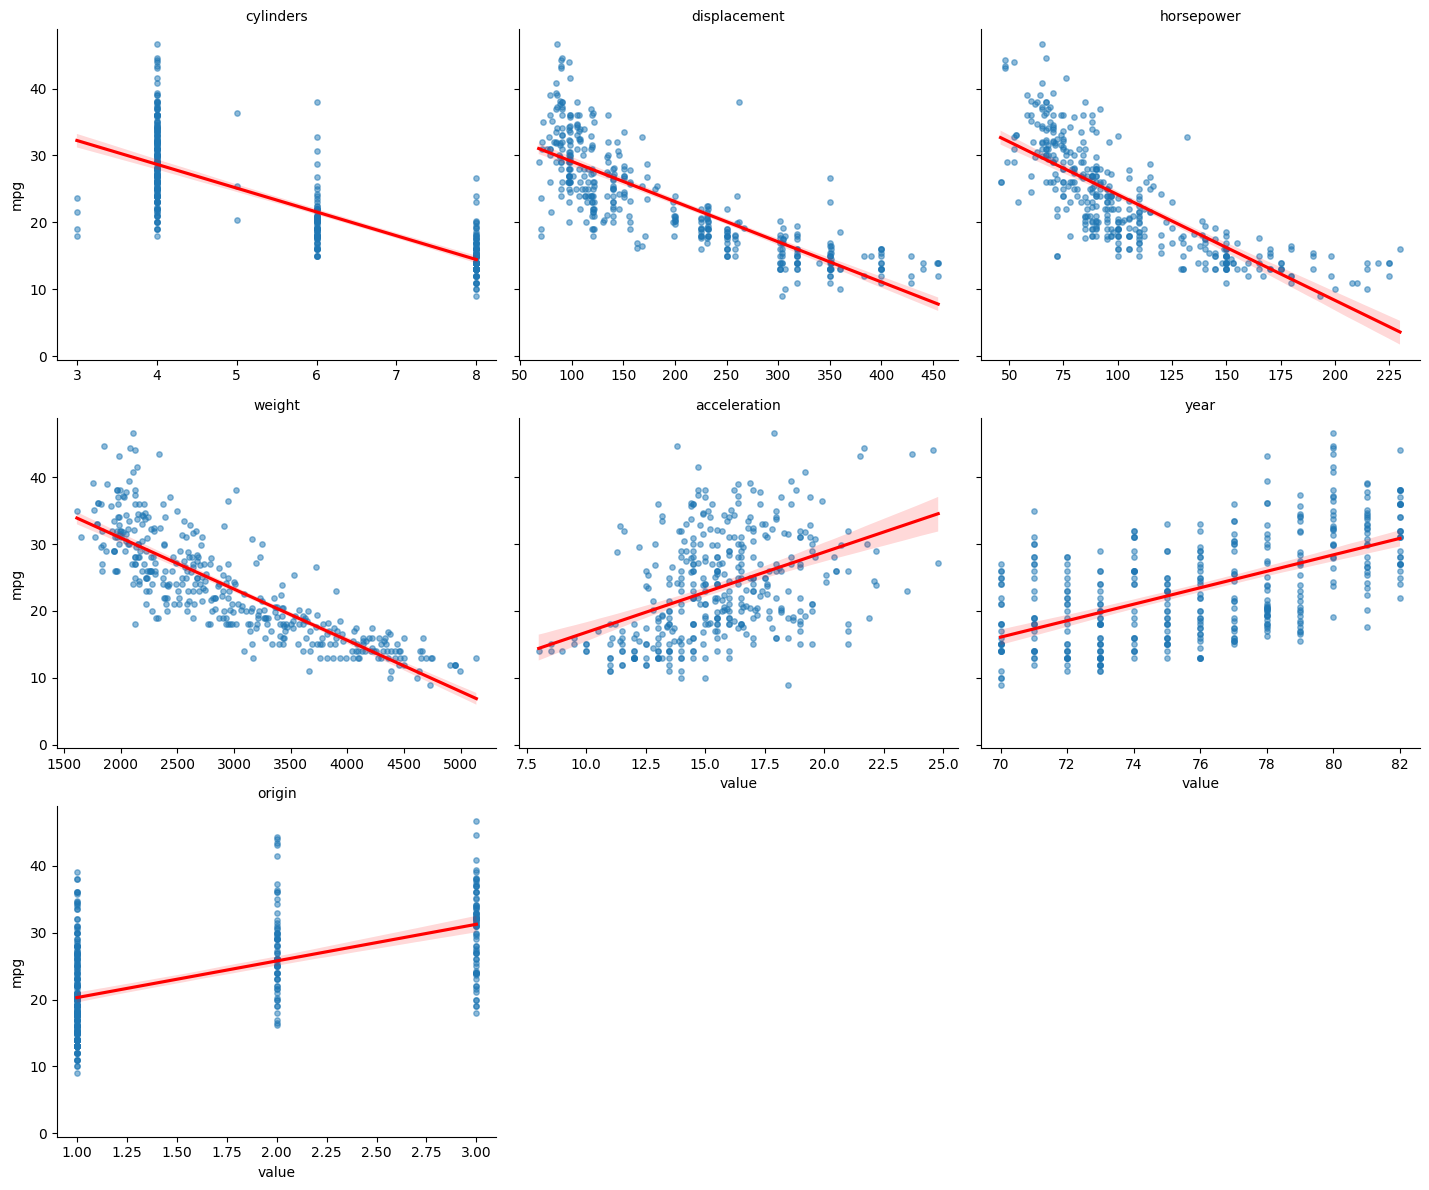

In [25]:
import warnings
warnings.filterwarnings('ignore')

# Filter for only numeric columns
numeric_df = auto_df.select_dtypes(include=['number'])
x_vars = [v for v in numeric_df.columns if v != 'mpg']

# 2. Reshape the data so all predictors are in a single column
df_melted = auto_df.melt(id_vars=['mpg'], value_vars=x_vars)

# 3. Create the grid
# col_wrap=3 handles the "3 per row" perfectly
g = sns.lmplot(
    data=df_melted, 
    x='value', 
    y='mpg', 
    col='variable', 
    col_wrap=3,
    sharex=False,  # Important: each variable has its own scale
    facet_kws={'sharey': True},
    scatter_kws={'s': 15, 'alpha': 0.5},
    line_kws={'color': 'red'},
    height=4, 
    aspect=1.2
)

# 4. Fix titles so they aren't "variable = weight"
g.set_titles("{col_name}")
plt.show()

- What you observe: The "shape" of the relationship and the "noise" (variance) around the line.
- Why it’s useful: * The Linearity Assumption: This is the ultimate test for ISLP Chapter 3. If the dots follow a curve (like a "U" or an arch) but the red line is straight, you are witnessing Underfitting. It tells the analyst: "A simple linear model will fail here; we need to square this term or use a spline."

<a id="1.4"></a>
### 1.4 Encoding Qualitative Data
Categorical variables (like origin) must be converted into numerical "Dummy Variables" so the math can process them.

- Action: Use Dummy Encoding for origin.

- Manual Logic: * Origin_2 = 1 if European, 0 otherwise.
    - Origin_3 = 1 if Japanese, 0 otherwise.
    - If both are 0, it defaults to American. This prevents the model from thinking the origins have a numerical ranking.

In [31]:
# Convert 'origin' to a categorical type first
auto_df['origin'] = auto_df['origin'].astype('category')

# Create dummy variables (dropping the first to avoid the Dummy Variable Trap)
auto_df_encoded = pd.get_dummies(auto_df, columns=['origin'], drop_first=True)

# Preview the new columns: origin_2 (European), origin_3 (Japanese)
auto_df_encoded.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,name,origin_2,origin_3
0,18.0,8,307.0,130,3504,12.0,70,chevrolet chevelle malibu,False,False
1,15.0,8,350.0,165,3693,11.5,70,buick skylark 320,False,False
2,18.0,8,318.0,150,3436,11.0,70,plymouth satellite,False,False
3,16.0,8,304.0,150,3433,12.0,70,amc rebel sst,False,False
4,17.0,8,302.0,140,3449,10.5,70,ford torino,False,False


<a id="1.5"></a>
### 1.5 Feature Scaling (Standardization)
To prepare for Regularization (Ridge/Lasso) in Phase 4, we must ensure all variables are on the same scale (Mean = 0, Std = 1).
- Action: Apply $Z$-score normalization: $z = \frac{x - \mu}{\sigma}$
- Why here? If we want to compare the "importance" of weight (thousands) vs. acceleration (tens), they must be on the same scale.


In [33]:
from sklearn.preprocessing import StandardScaler

# Select only numeric columns for scaling
# Note: Usually, we don't scale the Target (mpg) or Dummy Variables
numeric_cols = ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year']

scaler = StandardScaler()
auto_df_encoded[numeric_cols] = scaler.fit_transform(auto_df_encoded[numeric_cols])

# Verify the result (Mean should be approx 0, Std should be 1)
auto_df_encoded[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
cylinders,392.0,-0.0,1.0,-1.45,-0.86,-0.86,1.48,1.48
displacement,392.0,0.0,1.0,-1.21,-0.86,-0.42,0.78,2.49
horsepower,392.0,0.0,1.0,-1.52,-0.77,-0.29,0.56,3.27
weight,392.0,-0.0,1.0,-1.61,-0.89,-0.21,0.75,2.55
acceleration,392.0,-0.0,1.0,-2.74,-0.64,-0.01,0.54,3.36
year,392.0,-0.0,1.0,-1.63,-0.81,0.01,0.82,1.64


<a id="2"></a>
## Phase 2: The Baseline Model (Inference)
Goal: Establish a performance floor using Ordinary Least Squares (OLS) and evaluate the statistical significance of our predictors.

<a id="2.1"></a>
### 2.1 Fitting the OLS Model
We use statsmodels here because it automatically calculates p-values and confidence intervals, which scikit-learn does not do easily.

In [35]:
print(X.dtypes[X.dtypes == 'object'])

Series([], dtype: object)


In [36]:
import statsmodels.api as sm

# 1. Reset everything to be safe
# We ensure X and y are perfectly aligned by using the same index
X = auto_df_encoded.drop(columns=['mpg', 'name']).copy()
y = auto_df_encoded['mpg'].copy()

# 2. Force conversion to float and drop any stray non-numeric columns
X = X.select_dtypes(include=['number']).astype(float)

# 3. Add the constant
X = sm.add_constant(X)

# 4. Fit the model
# Using .values can sometimes bypass Pandas/Statsmodels alignment bugs
baseline_model = sm.OLS(y, X).fit()

display(baseline_model.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    mpg   R-squared:                       0.809
Model:                            OLS   Adj. R-squared:                  0.806
Method:                 Least Squares   F-statistic:                     272.2
Date:                Sun, 12 Apr 2026   Prob (F-statistic):          3.79e-135
Time:                        17:04:55   Log-Likelihood:                -1036.5
No. Observations:                 392   AIC:                             2087.
Df Residuals:                     385   BIC:                             2115.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           23.4459      0.174    135.130      0.000      23.105      23.787
cylinders       -0.5619      0.566     -0.993      0.321      -1.674       0.550
displacement     0.8025      0.769      1.044      0.297      -0.709       2.314
horsepower      -0.0150      0.532     -0.028      0.977      -1.061       1.031
weight          -5.7640      0.568    -10.141      0.000      -6.882      -4.646
acceleration     0.2350      0.281      0.836      0.404      -0.318       0.788
year             2.7717      0.194     14.318      0.000       2.391       3.152
==============================================================================
Omnibus:                       37.865   Durbin-Watson:                   1.232
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               60.248
Skew:                           0.630   Prob(JB):                     8.26e-14
Kurtosis:                       4.449   Cond. No.                         10.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<a id="2.2"></a>
### 2.2 The Analyst's Checklist (The "Three Pillars")
When you look at the summary output above, your manual should guide you to look at these three specific areas:
- A. The Global Fit (Is the model useful?)
    - R-squared / Adj. R-squared: This tells you the percentage of variance explained.
        - Observation: If $R^2$ is high (e.g., > 0.70), your linear baseline is strong.
- Prob (F-statistic): This tests if all coefficients are zero.
    - Observation: If this is $< 0.05$, your model is statistically better than just guessing the average mpg.
- B. The Feature Significance (Which variables matter?)
    - P > |t| (p-values): * Observation: If $p < 0.05$, the variable is a significant predictor. In the Auto dataset, you might find weight is significant, while acceleration is not. This tells the analyst: "We might be able to simplify this model."
    - Coef (Coefficients): * Observation: Since we scaled our data in Phase 1, you can compare these directly. A larger absolute coefficient means that variable has more "pull" on the mpg.
- C. The Residual Diagnostics (The "Straight Line" Test)
    - We must check if our errors are random. If they aren't, our model is missing something.

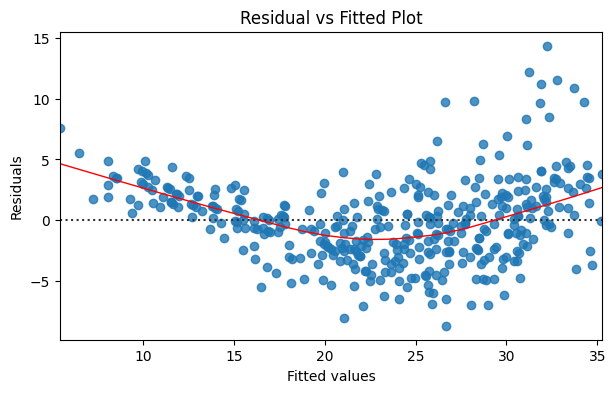

In [38]:
# Plotting Residuals vs Fitted values
plt.figure(figsize=(7, 4))
sns.residplot(x=baseline_model.fittedvalues, y=baseline_model.resid, lowess=True, 
              line_kws={'color': 'red', 'lw': 1})
plt.xlabel('Fitted values')
plt.ylabel('Residuals')
plt.title('Residual vs Fitted Plot')
plt.show()

<a id="3"></a>
## Phase 3: Validation Strategy
Goal: Shift from "explaining the past" to "predicting the future" by ensuring the model generalizes to unseen data.

<a id="3.1"></a>
### 3.1 The Train-Test Split
We set aside a "lockbox" of data (the Test Set) that the model never sees during training.

In [39]:
from sklearn.model_selection import train_test_split

# Define X (features) and y (target)
# We use the encoded and scaled dataframe from Phase 1
X = auto_df_encoded.drop(columns=['mpg', 'name'])
y = auto_df_encoded['mpg']

# Split: 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training observations: {len(X_train)}")
print(f"Test observations: {len(X_test)}")

Training observations: 313
Test observations: 79


<a id="3.2"></a>
### 3.2 Performance Metrics
A. We use MAE and RMSE to understand the error in real-world units (Miles Per Gallon).

In [49]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

# Make Predictions
# We predict on the 'Test' set (data the model has NEVER seen)
y_pred = model_lr.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f} MPG")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} MPG")
print(f"R-squared Score: {r2:.2f}")

Mean Absolute Error (MAE): 2.46 MPG
Root Mean Squared Error (RMSE): 3.26 MPG
R-squared Score: 0.79


<a id="3.3"></a>
### 3.3 K-Fold Cross-Validation
To avoid getting a "lucky" split, we use $k$-fold CV. This splits the training data into $k$ pieces, training on $k-1$ and validating on the last piece, repeating this $k$ times.

In [50]:
# 10-fold Cross-Validation
cv_mse = cross_val_score(model_lr, X_train, y_train, cv=10, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_mse)

print(f"CV RMSE Mean: {cv_rmse.mean():.3f}")

CV RMSE Mean: 3.396


<a id="3.4"></a>
### 3.4 Visual Validation
Once the model is trained, we evaluate it on the Test Set. We want to know not just "if" it's wrong, but "how" it's wrong.

B. Prediction Audit Table
Seeing the raw numbers side-by-side helps identify if specific rows are causing massive errors.

In [51]:
# Create a comparison table for the first 10 test samples
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison_df['Error'] = comparison_df['Actual'] - comparison_df['Predicted']

display(comparison_df.head(10))

,Actual,Predicted,Error
78,26.0,26.623086,-0.623086
274,21.6,26.902469,-5.302469
246,36.1,34.265982,1.834018
55,26.0,24.441176,1.558824
387,27.0,28.235414,-1.235414
203,28.0,30.182539,-2.182539
42,13.0,8.561005,4.438995
233,26.0,30.349163,-4.349163
150,19.0,20.381536,-1.381536
116,29.0,29.446287,-0.446287


C. Visualizing the "Perfect Fit"
In a perfect world, all dots would fall on the red dashed line ($y=x$). Deviations from this line show the model's limitations.

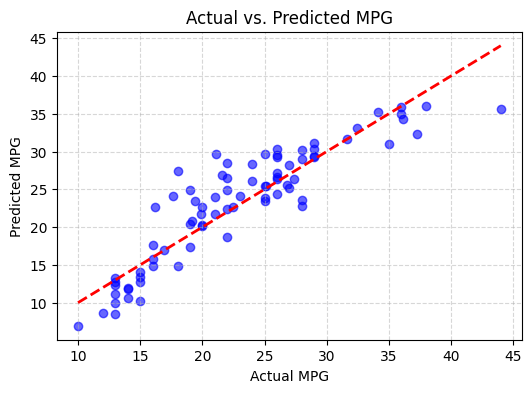

In [53]:
plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_pred, alpha=0.6, color='blue')

# Draw the 'Perfect Prediction' line
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

plt.xlabel('Actual MPG')
plt.ylabel('Predicted MPG')
plt.title('Actual vs. Predicted MPG')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

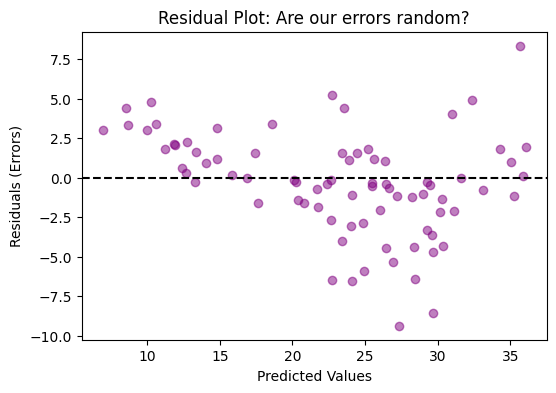

In [54]:
residuals = y_test - y_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_pred, residuals, color='purple', alpha=0.5)
plt.axhline(y=0, color='black', linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Plot: Are our errors random?')
plt.show()

Why this is useful for the Analyst:
- The Identity Line ($y=x$): If the dots curve away from the red line at the high end, it tells the analyst the model is "clueless" about high-efficiency cars.
- The Residual Pattern: If you see a "U-shape" in the purple dots, your model is biased. It means the relationship in the data is actually non-linear (Chapter 7), and no matter how much you "tune" a linear model, you won't fix it.
- MAE vs. RMSE: If your RMSE is much higher than your MAE, it tells you that you have a few outliers where the model is massively wrong, as RMSE penalizes large errors more heavily.

<a id="4"></a>
## Phase 4: Model Refinement (Flexibility & Regularization)
Goal: Improve performance by capturing non-linear relationships and interactions, while using Ridge/Lasso to prevent overfitting.

<a id="4.1"></a>
### 4.1 Feature Engineering (The "Flexibility" Boost)
If our residual plot in Phase 3 showed a "U-shape," we need to add non-linear terms. We can also add Interactions (e.g., how horsepower and weight work together).

In [55]:
from sklearn.preprocessing import PolynomialFeatures

# 1. Create Polynomial & Interaction terms (Degree 2)
# interaction_only=False includes squared terms like horsepower^2
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X) # X is our scaled features from Phase 1

# Get the names of the new features (e.g., 'horsepower^2' or 'horsepower weight')
poly_feature_names = poly.get_feature_names_out(X.columns)
X_poly_df = pd.DataFrame(X_poly, columns=poly_feature_names)

# 2. Re-split the expanded data
X_train_p, X_test_p, y_train, y_test = train_test_split(X_poly_df, y, test_size=0.2, random_state=42)

print(f"Original features: {X.shape[1]}")
print(f"Expanded features (Squares + Interactions): {X_poly_df.shape[1]}")

Original features: 8
Expanded features (Squares + Interactions): 44


<a id="4.2"></a>
### 4.2 Automated Regularization (Ridge & Lasso)
Now that we have many features, we use Cross-Validation to find the optimal penalty ($\alpha$). This prevents the model from assigning too much importance to "noisy" interaction terms.

In [56]:
from sklearn.linear_model import RidgeCV, LassoCV

# Define a range of alphas to test
alphas = np.logspace(-3, 3, 100)

# 1. Ridge Regression (L2): Shrinks coefficients
ridge_model = RidgeCV(alphas=alphas, cv=10).fit(X_train_p, y_train)

# 2. Lasso Regression (L1): Performs Feature Selection
lasso_model = LassoCV(alphas=alphas, cv=10, max_iter=10000).fit(X_train_p, y_train)

print(f"Optimal Ridge Alpha: {ridge_model.alpha_:.4f}")
print(f"Optimal Lasso Alpha: {lasso_model.alpha_:.4f}")

Optimal Ridge Alpha: 2.4771
Optimal Lasso Alpha: 0.0107


<a id="4.3"></a>
### 4.3 Evaluating the "Shrinkage"
The analyst should check which features actually survived the Lasso penalty. This is essentially "Automated Data Science."

In [57]:
# Create a coefficient comparison table
coef_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Ridge_Coef': ridge_model.coef_,
    'Lasso_Coef': lasso_model.coef_
})

# Filter for Lasso's chosen features
significant_features = coef_df[coef_df['Lasso_Coef'] != 0]
print(f"Lasso kept {len(significant_features)} out of {len(poly_feature_names)} features.")
display(significant_features.sort_values(by='Lasso_Coef', ascending=False))

Lasso kept 29 out of 44 features.


,Feature,Ridge_Coef,Lasso_Coef
5,year,2.531609,2.641934
43,origin_3^2,1.186251,2.572191
36,acceleration origin_2,2.311085,2.550855
15,cylinders origin_3,2.040497,2.511982
11,cylinders weight,1.413424,2.299709
20,displacement year,1.972339,1.747582
37,acceleration origin_3,1.295386,1.410648
35,acceleration year,0.781773,0.848262
12,cylinders acceleration,1.271791,0.835879
39,year origin_2,0.807197,0.516226


#### Why is Phase 4 useful to the analyst?
- 1. Capturing Complexity without ChaosBy adding squared terms (like $horsepower^2$), you allow the model to follow the curve we saw in the Auto dataset. By using Lasso, you ensure that if $horsepower^2$ is useful but $acceleration^2$ is useless, the model automatically ignores the latter.
- 2. Solving MulticollinearityInteraction terms and squared terms are naturally highly correlated with the original variables. A standard OLS model would produce wild, unreliable coefficients. Ridge Regression stabilizes these by spreading the "penalty" across all correlated features.
- 3. The "Elbow" of the Bias-Variance TradeoffIn this phase, you are actively finding the "sweet spot" on the curve. By increasing flexibility (Poly features) and then controlling it (Regularization), you reach a lower total error than you ever could with a simple straight line.

<a id="5"></a>
## Phase 5: Final Evaluation (The Result)
Goal: Now that Lasso has picked our "Best Features," we run the final test. This is the last block of your manual.

In [67]:
# 1. Final Predictions using the Lasso model
y_pred_final = lasso_model.predict(X_test_p)

# 2. Final Metric Calculation
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred_final))
final_r2 = r2_score(y_test, y_pred_final)

print(f"--- FINAL MODEL PERFORMANCE ---")
print(f"Final Test RMSE: {final_rmse:.2f} MPG")
print(f"Final Test R-squared: {final_r2:.4f}")

--- FINAL MODEL PERFORMANCE ---
Final Test RMSE: 2.66 MPG
Final Test R-squared: 0.8610


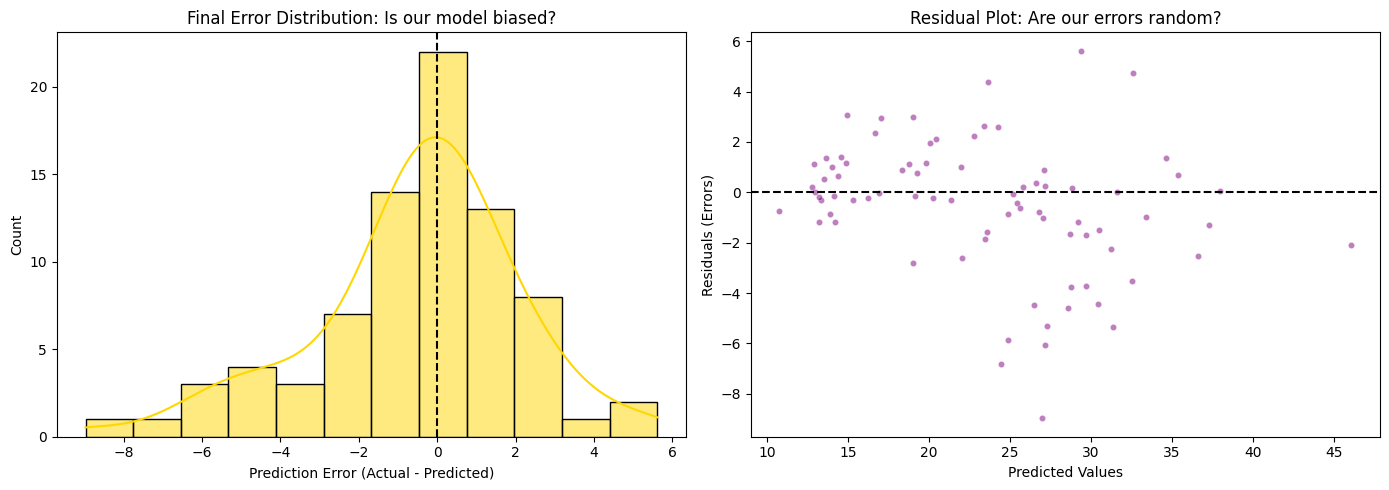

In [72]:
# Calculate residuals
final_errors = y_test - y_pred_final

# Create a figure with 1 row and 2 columns
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Error Distribution (Left Plot)
sns.histplot(final_errors, kde=True, color='gold', ax=ax[0])
ax[0].axvline(x=0, color='black', linestyle='--')
ax[0].set_title('Final Error Distribution: Is our model biased?')
ax[0].set_xlabel('Prediction Error (Actual - Predicted)')

# 2. Residual Plot (Right Plot)
sns.scatterplot(x=y_pred_final, y=final_errors, color='purple', alpha=0.5, s=20, ax=ax[1])
ax[1].axhline(y=0, color='black', linestyle='--')
ax[1].set_title('Residual Plot: Are our errors random?')
ax[1].set_xlabel('Predicted Values')
ax[1].set_ylabel('Residuals (Errors)')

plt.tight_layout()
plt.show()

<a id="6"></a>
## Phase 6: The Post-Mortem (Troubleshooting)
Goal: Diagnose why the model is underperforming and determine the next steps for improvement.

<a id="6.1"></a>
### 6.1 Identify the "Failure Mode"

| Symptom | Diagnosis | Potential Fix |
| :--- | :--- | :--- |
| **High Training Error & High Test Error** | High Bias (Underfitting) | Your model is too simple. Add non-linear terms ($X^2$), interactions, or move to more complex models (Trees/Boosting). |
| **Low Training Error but High Test Error** | High Variance (Overfitting) | Your model "memorized" the noise. Increase the Lasso/Ridge penalty ($\alpha$), or gather more data. |
| **Residuals show a clear pattern (e.g., U-shape)** | Functional Misspecification | You are using a straight line for a curved relationship. You need Polynomials or Log-transformations. |
| **Error distribution is "Skewed" (not a bell curve)** | Target Skewness | Your target ($y$) might need a log-transform (common with prices or salaries). |

<a id="6.2"></a>
### 6.2 The "Outlier" Audit

In [73]:
# Calculate absolute errors
comparison_df['Abs_Error'] = comparison_df['Error'].abs()

# Look at the top 1% of errors
threshold = comparison_df['Abs_Error'].quantile(0.99)
outliers = comparison_df[comparison_df['Abs_Error'] > threshold]

print(f"Top 1% of errors contribute heavily to RMSE. Inspecting {len(outliers)} rows:")
display(outliers)

Top 1% of errors contribute heavily to RMSE. Inspecting 1 rows:


,Actual,Predicted,Error,Abs_Error
110,18.0,27.367018,-9.367018,9.367018


<a id="6.3"></a>
### 6.3 Checking for Multi-Collinearity (VIF)

In [75]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1. Ensure we are only looking at numeric columns
# 2. IMPORTANT: If X_train already has a 'const' column from sm.add_constant, 
#    keep it! VIF requires the intercept to be present for the math to be valid.
X_vif = X_train.select_dtypes(include=['number'])

# If you haven't added a constant yet, uncomment the line below:
# import statsmodels.api as sm
# X_vif = sm.add_constant(X_vif)

# 3. Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif.values, i) 
    for i in range(len(X_vif.columns))
]

# 4. Display, usually excluding the 'const' row from the final view 
# as its VIF doesn't matter for multicollinearity checks
display(vif_data[vif_data["Feature"] != 'const'].sort_values(by="VIF", ascending=False))

,Feature,VIF
1,displacement,19.271259
0,cylinders,10.961738
3,weight,10.029538
2,horsepower,9.380948
4,acceleration,2.677462
5,year,1.278661
